In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation

from itertools import combinations

from adjustText import adjust_text

from matplotlib_venn import venn3

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = ["Montserrat", "DejaVu Sans"]

path_to_images = '/home/gterren/india_power/images/'

In [3]:
def _time_features(df_, column = "datetime"):
    df_["time"]  = pd.to_datetime(df_[column])
    df_["month"] = df_["time"].dt.month
    df_["day"]   = df_["time"].dt.day
    df_["hour"]  = df_["time"].dt.hour
    return df_

def _iterations(df_):
    iter = 1
    df_.loc[df_['FY'] == 2000, 'iteration'] = iter
    df_.loc[df_['FY'] == 2020, 'iteration'] = iter

    for fy in [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
               2011, 2012, 2013, 2014]:
        iter += 1
        df_.loc[df_['FY'] == fy, 'iteration'] = iter

    iter += 1

    df_.loc[df_['FY'] == 2015, 'iteration'] = iter
    df_.loc[df_['FY'] == 2017, 'iteration'] = iter

    for fy in [2018, 2019]:
        iter += 1
        df_.loc[df_['FY'] == fy, 'iteration'] = iter
    return df_

In [21]:
path_to_csvs = '/home/abhis/india_power/gridpath_india_viz/processed_data/'

LOLH_ = pd.read_csv(path_to_csvs + 'lz_lolh_filtered-ra-8_prm_90_ccap.csv')

LOLH_ = _time_features(LOLH_, column = "timestamp")
print(LOLH_.columns)
USE_ = LOLH_[['month', 
              'day', 
              'hour', 
              'iteration', 
              'load_zone',
              'unserved_energy',
              'static_load']].copy()

USE_['normalized_unserved_energy'] =  100 * USE_['unserved_energy'] / USE_['static_load']

Index(['timepoint', 'load_zone', 'static_load', 'net_imports',
       'overgeneration', 'unserved_energy', 'W', 'H', 'A', 'W-H-A',
       'iteration', 'timestamp', 'capacity_mw_vre',
       'available_capacity_mw_vre', 'power_mw_vre', 'availability_derate',
       'vre_cap_factor', 'Hydro ROR_capacity_mw', 'Solar_capacity_mw',
       'Wind_capacity_mw', 'Hydro ROR_power_mw', 'Solar_power_mw',
       'Wind_power_mw', 'solar_cap_factor', 'wind_cap_factor',
       'capacity_mw_thermal', 'available_capacity_mw_thermal',
       'power_mw_thermal', 'thermal_availability', 'plf', 'power_mw',
       'net_load', 'max_static_load', 'max_net_load',
       'overall_max_static_load', 'overall_max_net_load', 'static_load_pct',
       'net_load_pct', 'lost_load_pct', 'overall_static_load_pct',
       'overall_net_load_pct', 'max_unserved_energy',
       'overall_max_unserved_energy', 'overall_unserved_energy_pct',
       'unserved_energy_pct', 'zone_transmission_flow_mw', 'zone_max_mw',
       'tx_ca

In [5]:
path_to_data = '/home/gterren/india_power/gridpath_india_viz/data/'

t2m_ = pd.read_csv(path_to_data + 'avg_t2m.csv')
t2m_ = _time_features(t2m_, column = "datetime")
t2m_ = _iterations(t2m_).drop(columns   = ['datetime', 'year', 'time', 'FY'])
print(t2m_.shape)

ghi_ = pd.read_csv(path_to_data + 'avg_ghi.csv')
ghi_ = _time_features(ghi_, column = "datetime")
ghi_ = _iterations(ghi_).drop(columns = ['datetime', 'year', 'time', 'FY'])
print(ghi_.shape)

tcc_ = pd.read_csv(path_to_data + 'avg_tcc.csv')
tcc_ = _time_features(tcc_, column = "datetime")
tcc_ = _iterations(tcc_).drop(columns = ['datetime', 'year', 'time', 'FY'])
print(tcc_.shape)

tp_ = pd.read_csv(path_to_data + 'avg_tp.csv')
tp_ = _time_features(tp_, column = "datetime")
tp_ = _iterations(tp_).drop(columns = ['datetime', 'year', 'time', 'FY'])
print(tp_.shape)

cs_ = pd.read_csv(path_to_data + 'avg_cs.csv')
cs_ = _time_features(cs_, column = "datetime")
cs_ = _iterations(cs_).drop(columns = ['datetime', 'year', 'time', 'FY'])
print(cs_.shape)

wnd10m_  = pd.read_csv(path_to_data + 'avg_wnd10m.csv')
wnd10m_  = _time_features(wnd10m_, column = "datetime")
wnd10m_  = _iterations(wnd10m_).drop(columns = ['datetime', 'year', 'time', 'FY'])
print(wnd10m_.shape)

wnd100m_ = pd.read_csv(path_to_data + 'avg_wnd100m.csv')
wnd100m_ = _time_features(wnd100m_, column = "datetime")
wnd100m_ = _iterations(wnd100m_).drop(columns = ['datetime', 'year', 'time', 'FY'])
print(wnd100m_.shape)

(5518800, 9)
(5518800, 9)
(5518800, 9)
(5518800, 9)
(5518800, 9)
(5518800, 9)
(5518800, 9)


In [6]:
df_1_ = t2m_.merge(USE_, 
                   on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                   how = "inner")

df_1_ = ghi_.merge(df_1_, 
                   on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                   how = "inner")

df_1_ = tcc_.merge(df_1_, 
                   on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                   how = "inner")

df_1_ = tp_.merge(df_1_, 
                  on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                  how = "inner")

df_1_ = cs_.merge(df_1_,
                  on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                  how = "inner")

df_1_ = wnd10m_.merge(df_1_, 
                      on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                      how = "inner")

df_1_ = wnd100m_.merge(df_1_, 
                       on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                       how = "inner")
print(df_1_.shape)

(210, 36)


In [7]:
idx_ghi_   = df_1_['ghi_solar'] < 200
idx_t2m_   = df_1_['t2m_pow'] > 34
idx_wind_  = df_1_['wnd100m_wind'] < 14

idxs_   = [idx_ghi_, idx_wind_, idx_t2m_]
labels_ = ['Low GHI', 'Low Wind (100m)', 'High Temp. (2m)']
idx_    = [0, 1, 2]

k             = 0
combinations_ = [()]
df_1_['set']  = 0
for r in range(1, len(idx_) + 1):
    for idx_p_ in combinations(idx_, r):
        combinations_.append(idx_p_)
        
        idx_cat_ = pd.Series([True] * df_1_.shape[0])
        for i in idx_p_:
            idx_cat_ = idx_cat_ & idxs_[i]

        k += 1
        df_1_.loc[idx_cat_, 'set'] = k

df_venn_ = df_1_[['set', 
                  'unserved_energy', 
                  'normalized_unserved_energy']].copy()

df_venn_["event"] = 1

for idx_, label in zip(idxs_, labels_):
    df_venn_[label]           = 0
    df_venn_.loc[idx_, label] = 1

df_venn_agg_ = df_venn_.groupby(['set']).agg({'unserved_energy': 'sum', 
                                              'event': 'sum'}).reset_index(drop = False)

(210,) 629381.4725226907
195 15


/home/gterren/miniconda3/envs/ra/lib/python3.9/site-packages/matplotlib_venn/_venn3.py:165: UserWarning: normalize_to is deprecated. Please use layout_algorithm=matplotlib_venn.layout.venn3.DefaultLayoutAlgorithm(normalize_to) instead.
  warnings.warn(


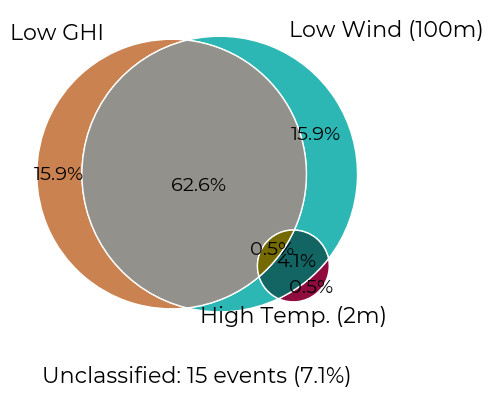

/home/gterren/miniconda3/envs/ra/lib/python3.9/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


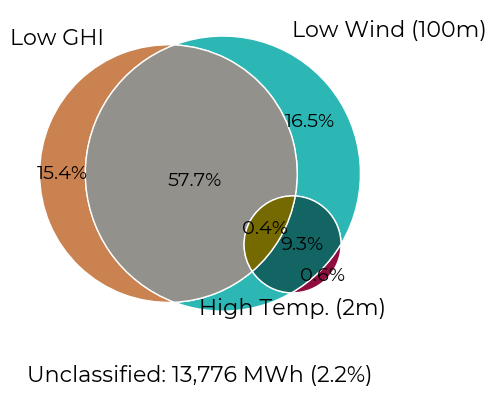

In [37]:
def _plot_venn_diagram_energy(ax, A, B, C, w_, labels_):

    # Weighted subsets (sum of weights in each region)
    only_A        = w_[ A & ~B & ~C].sum()
    only_B        = w_[~A &  B & ~C].sum()
    A_and_B       = w_[ A &  B & ~C].sum()
    only_C        = w_[~A & ~B &  C].sum()
    A_and_C       = w_[ A & ~B &  C].sum()
    B_and_C       = w_[~A &  B &  C].sum()
    A_and_B_and_C = w_[ A &  B &  C].sum()

    subsets = (only_A,
               only_B,
               A_and_B,
               only_C,
               A_and_C,
               B_and_C,
               A_and_B_and_C)

    total = sum(subsets)
    unclassified = w_.sum() - total
    
    v = venn3(subsets=subsets,
              set_labels=labels_,
              ax=ax, normalize_to=1.0)

    for patch_id, color in zip(['100', '010', '001', '110', '011', '111'],
                            ['#ca8250', "#2cb7b5", '#900C3F', "#92918b", '#136564', '#756a01']):
        
        patch = v.get_patch_by_id(patch_id)
        if patch:
            patch.set_linewidth(1)       # outline thickness
            patch.set_color(color)
            patch.set_alpha(1)
            patch.set_edgecolor("w")   # outline color

    for text in v.set_labels:
        if text:
            text.set_fontsize(16)
            #text.set_fontweight("bold")

    for text, value in zip(v.subset_labels, subsets):
        if text:
            # text.set_fontsize(12)
            # text.set_text(f"{value:,.0f} MWh")  # or "{:.0f}" if you want integer-ish
            value = 100 * value / total
            text.set_fontsize(14)
            text.set_text(f"{value:,.1f}%") 

    total_all = total + unclassified   # where `total = sum(venn subsets)`
    pct = 100 * unclassified / total_all if total_all else 0

    ax.text(
        0.5, -0.08,
        f"Unclassified: {unclassified:,.0f} MWh ({pct:.1f}%)", fontsize = 16,
        transform=ax.transAxes,
        ha="center", va="top")
    
def _plot_venn_diagram_counts(ax, A, B, C, w_, labels_):

    # Compute Venn region counts
    only_A        = np.sum( A & ~B & ~C)
    only_B        = np.sum(~A &  B & ~C)
    A_and_B       = np.sum( A &  B & ~C)
    only_C        = np.sum(~A & ~B &  C)
    A_and_C       = np.sum( A & ~B &  C)
    B_and_C       = np.sum(~A &  B &  C)
    A_and_B_and_C = np.sum( A &  B &  C)

    subsets = (only_A,
               only_B,
               A_and_B,
               only_C,
               A_and_C,
               B_and_C,
               A_and_B_and_C)
    
    total = sum(subsets)
    unclassified = w_.shape[0] - total
    print(total, unclassified)

    v = venn3(subsets=subsets,
              set_labels=labels_,
              ax=ax, normalize_to=1.0)

    for patch_id, color in zip(['100', '010', '001', '110', '011', '111'],
                               ['#ca8250', "#2cb7b5", '#900C3F', "#92918b", '#136564', '#756a01']):
        
        patch = v.get_patch_by_id(patch_id)
        if patch:
            patch.set_linewidth(1)       # outline thickness
            patch.set_color(color)
            patch.set_alpha(1)
            patch.set_edgecolor("w")   # outline color

    for text in v.set_labels:
        if text:
            text.set_fontsize(16)
            #text.set_fontweight("bold")
            
    for text, value in zip(v.subset_labels, subsets):
        if text:
            # text.set_fontsize(12)
            # text.set_text(f"{value:,.0f}")  # or "{:.0f}" if you want integer-ish
            value = 100 * value / total
            text.set_fontsize(14)
            text.set_text(f"{value:,.1f}%")  # or "{:.0f}" if you want integer-ish

    total_all = total + unclassified   # where `total = sum(venn subsets)`
    pct = 100 * unclassified / total_all if total_all else 0

    ax.text(0.5, -0.08,
            f"Unclassified: {unclassified} events ({pct:.1f}%)", fontsize = 16,
            transform=ax.transAxes,
            ha="center", 
            va="top")

A = (df_venn_["Low GHI"] == 1).to_numpy()
B = (df_venn_["Low Wind (100m)"] == 1).to_numpy()
C = (df_venn_["High Temp. (2m)"] == 1).to_numpy()

labels_ = ['Low GHI', 'Low Wind (100m)', 'High Temp. (2m)']

# weights for each element (e.g., unserved_energy per hour)
w_ = df_venn_['unserved_energy'].to_numpy()
print(w_.shape, w_.sum())
# Plot Venn diagram
fig, ax = plt.subplots(figsize=(5, 5))

_plot_venn_diagram_counts(ax, A, B, C, w_, labels_)

plt.savefig(path_to_images + '/venn_diagram-counts.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()


# Plot Venn diagram
fig, ax = plt.subplots(figsize=(5, 5))

_plot_venn_diagram_energy(ax, A, B, C, w_, labels_)

plt.savefig(path_to_images + '/venn_diagram-energy.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

In [38]:
idx_night_ = df_1_['cs_solar'] < 200
idx_tcc_   = df_1_['tcc_solar'] > 25
idx_t2m_   = df_1_['t2m_pow'] > 34
idx_wind_  = df_1_['wnd100m_wind'] < 14

idxs_   = [idx_night_, idx_tcc_, idx_wind_, idx_t2m_]
labels_ = ['Night', 'High Cloud Cover', 'Low Wind (100m)', 'High Temp. (2m)']
idx_    = [0, 1, 2, 3]

k             = 0
combinations_ = [()]
df_1_['set']  = 0
for r in range(1, len(idx_) + 1):
    for idx_p_ in combinations(idx_, r):
        combinations_.append(idx_p_)
        
        idx_cat_ = pd.Series([True] * df_1_.shape[0])
        for i in idx_p_:
            idx_cat_ = idx_cat_ & idxs_[i]

        k += 1
        df_1_.loc[idx_cat_, 'set'] = k

df_upset_ = df_1_[['set', 
                   'unserved_energy', 
                   'normalized_unserved_energy']].copy()

df_upset_["event"] = 1

for idx_, label in zip(idxs_, labels_):
    df_upset_[label]           = 0
    df_upset_.loc[idx_, label] = 1

df_upset_agg_ = df_upset_.groupby(['set']).agg({'unserved_energy': 'sum', 
                                                'event': 'sum'}).reset_index(drop = False)

[0 0 0 0]
[1 0 0 0]
[0 1 0 0]
[0 0 1 0]
[0 0 0 1]
[1 1 0 0]
[1 0 1 0]
[1 0 0 1]
[0 1 1 0]
[0 1 0 1]
[0 0 1 1]
[1 1 1 0]
[1 1 0 1]
[1 0 1 1]
[0 1 1 1]
[1 1 1 1]


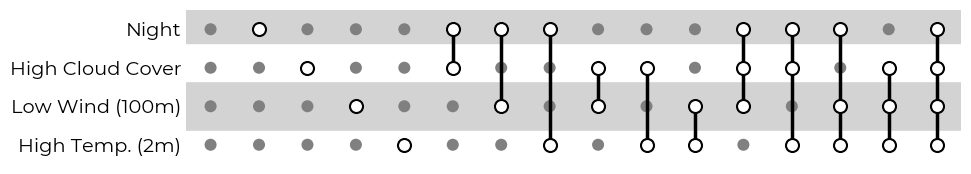

In [39]:
def _plot_upset_matrix(ax, combinations_, indicator_cols):

    n_combos = len(combinations_)
    n_sets   = len(indicator_cols)

    comb_matrix = np.zeros((n_combos, n_sets), dtype=int)

    for i, combo in enumerate(combinations_):
        comb_matrix[i, list(combo)] = 1
    comb_matrix = np.asarray(comb_matrix)

    n_combos, n_sets = comb_matrix.shape
    # Loop over sets (rows) and combinations (columns)
    for j_combo in range(n_combos):
        print(comb_matrix[j_combo])
        for i_set in range(n_sets):
            ax.scatter(j_combo, i_set,
                       s = 75,   
                       marker="o", 
                       edgecolor="None", 
                       facecolor="gray", 
                       lw = 0, 
                       zorder = 1)
                
            if comb_matrix[j_combo, i_set]:      # membership = 1
                ax.scatter(j_combo, i_set,    
                           s = 87.5,
                           marker="o", 
                           edgecolor="black", 
                           facecolor="w", 
                           lw = 1.5, 
                           zorder = 3)

        # --- connect members in this column when there are 2+ ---
        ys = [i for i in range(n_sets) if comb_matrix[j_combo, i]]

        if len(ys) >= 2:
            ys_sorted = sorted(ys)

            # draw a small vertical segment between each consecutive pair
            for k in range(len(ys_sorted) - 1):
                y0 = ys_sorted[k]
                y1 = ys_sorted[k + 1]

                ax.plot([j_combo, j_combo],  [y0, y1],
                    color = 'k',
                    linewidth=2.5,
                    zorder=2)
                
    # Formatting
    ax.set_ylim(-0.5, n_sets - 0.5)
    ax.set_xlim(-0.5, n_combos - 0.5)

    # Set names on y-axis (invert so first set is at the top)
    ax.set_yticks(range(n_sets))
    ax.set_yticklabels(indicator_cols, fontsize = 14)
    ax.invert_yaxis()

    # Hide x tick labels (optional, or you can show combo indices)
    ax.set_xticks([]) 
    ax.set_xticklabels("")  # or "" to hide
    ax.tick_params(axis="both", which="both", length=0)

    # Optional: grid lines to make it look like a “table”
    #ax.grid(axis="y", linestyle="-", linewidth=21, color = 'lightgray', zorder = 1)

    ax.axhline(y=0, color = 'lightgray', linestyle="-", linewidth=35, zorder = 0)
    ax.axhline(y=1, color = 'white', linestyle="-", linewidth=35, zorder = 0)
    ax.axhline(y=2, color = 'lightgray',  linestyle="-", linewidth=35, zorder = 0)

    for spine in ax.spines.values():
        spine.set_visible(False)

fig, _ax = plt.subplots(figsize=(10, 2))

_plot_upset_matrix(_ax, combinations_, labels_)

plt.savefig(path_to_images + '/upset_combinations.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

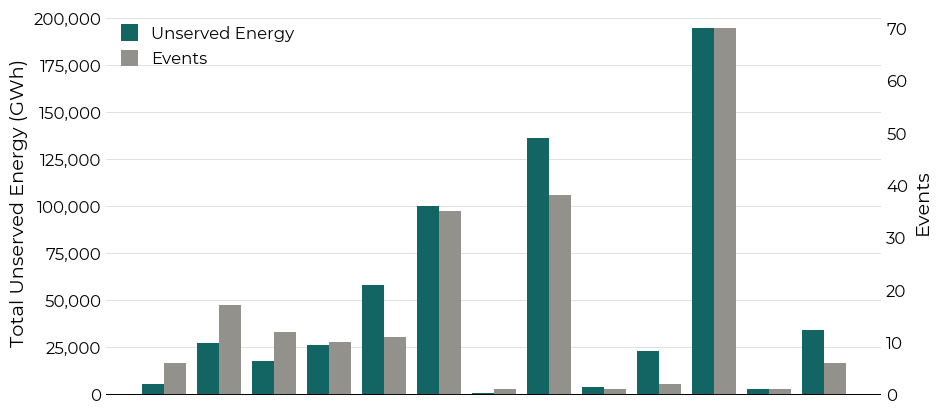

In [40]:
def _plot_all_sets_USE_and_events(ax1, df):

    x = np.arange(len(df))          # one position per "set"
    width = 0.4                     # bar width

    # --- Right y-axis: event number ---
    ax2 = ax1.twinx()

    # --- Left y-axis: unserved_energy ---
    bars1 = ax1.bar(x - width/2,
                    df["unserved_energy"],
                    width,
                    label="Unserved Energy",
                    color = '#136564', 
                    zorder = 4)

    ax1.set_ylabel("Total Unserved Energy (GWh)", fontsize = 14)
    ax1.tick_params(axis="y")

    bars2 = ax2.bar(x + width/2,
                    df["event"],
                    width,
                    label="Events",
                    color="#92918b", 
                    zorder = 4)

    ax2.set_ylabel("Events", fontsize = 14)
    ax2.tick_params(axis="y")

    # --- Combined legend ---
    handles = [bars1, bars2]
    labels = [h.get_label() for h in handles]
    ax1.legend(handles, labels, 
               frameon=False, 
               loc="upper left", 
               fontsize = 12)

    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax1.tick_params(axis="both", which="both", length=0)
    ax2.tick_params(axis="both", which="both", length=0)

    for spine in ["top", "left", "right", "bottom"]:
        ax1.spines[spine].set_visible(False)

    for spine in ["top", "left", "right", "bottom"]:
        ax2.spines[spine].set_visible(False)

    # Primary grid (unserved energy) – solid
    ax1.grid(axis="y", 
             linestyle="-", 
             linewidth=0.5,
             color="lightgray", 
             zorder=0)
    
    ax1.tick_params(axis="y", labelsize=12)

    ax2.tick_params(axis="y", labelsize=12)

    ax1.set_xticks([]) 
    ax1.set_xticklabels("")  # or "" to hide

    ax1.axhline(y=0, color = 'k', linestyle="-", linewidth=2, zorder = 10)
    ax2.axhline(y=0, color = 'k', linestyle="-", linewidth=2, zorder = 10)

fig, _ax = plt.subplots(figsize = (10, 5))

_plot_all_sets_USE_and_events(_ax, df_upset_agg_)

plt.savefig(path_to_images + '/upset_allsets.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

    set  unserved_energy  event          avg           std    deviation  \
0     0      5665.960846      6  2997.054631    944.326808 -2052.727823   
1     1     27326.721917     17  2997.054631   1607.454230 -1389.600401   
2     2     17550.499310     12  2997.054631   1462.541609 -1534.513022   
3     3     26246.128238     10  2997.054631   2624.612824  -372.441807   
4     5     57867.914326     11  2997.054631   5260.719484  2263.664853   
5     6     99923.064055     35  2997.054631   2854.944687  -142.109944   
6     7       572.833937      1  2997.054631    572.833937 -2424.220694   
7     8    136038.641464     38  2997.054631   3579.964249   582.909618   
8     9      3773.381751      1  2997.054631   3773.381751   776.327120   
9    10     22931.245756      2  2997.054631  11465.622878  8468.568247   
10   11    194583.891193     70  2997.054631   2779.769874  -217.284757   
11   13      2676.544286      1  2997.054631   2676.544286  -320.510345   
12   14     34224.645444 

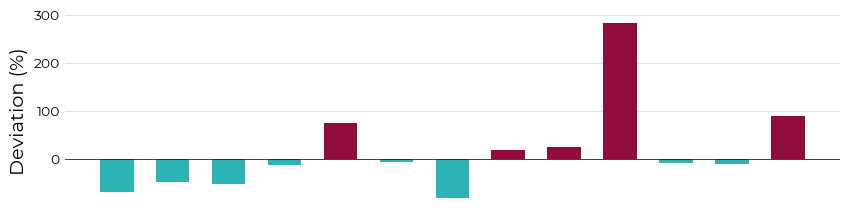

In [41]:
def _plot_upset_deviations(ax, df):

    df['avg']             = df['unserved_energy'].sum()/df['event'].sum() 
    df['std']             = df['unserved_energy']/df['event'] 
    df['deviation']       = df['std'] - df['avg']
    df['deviation_fract'] = 100.*df['deviation']/df['avg']

    print(df)

    x = np.arange(len(df))          # one position per "set"
    width = 0.6                     # bar width

    idx_ = df["deviation_fract"] > 0.

    # --- Left y-axis: unserved_energy ---
    bars1 = ax.bar(x[idx_], df.loc[idx_, "deviation_fract"], width,
                   color="#900C3F", 
                   zorder = 4)

    ax.set_ylabel("Deviation (%)", fontsize = 14)
    ax.tick_params(axis="y")

    bars2 = ax.bar(x[~idx_], df.loc[~idx_, "deviation_fract"], width,
                   color = '#2cb4b4', 
                   zorder = 4)

    ax.tick_params(axis="both", which="both", length=0)

    for spine in ["top", "left", "right", "bottom"]:
        ax.spines[spine].set_visible(False)

    #ax.set_ylim(-150,150)

    # Primary grid (unserved energy) – solid
    ax.grid(axis="y", 
            linestyle="-", 
            linewidth=0.5,
            color="lightgray", 
            zorder=0)

    ax.set_xticks([]) 
    ax.set_xticklabels("")  # or "" to hide

    ax.axhline(y=0, color = 'k', linestyle="-", linewidth=.5, zorder = 10)

fig, _ax = plt.subplots(figsize = (10, 2.5))

_plot_upset_deviations(_ax, df_upset_agg_)

plt.savefig(path_to_images + '/upset_deviations.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

[0 0 0 0]
[1 0 0 0]
[0 1 0 0]
[0 0 1 0]
[0 0 0 1]
[1 1 0 0]
[1 0 1 0]
[1 0 0 1]
[0 1 1 0]
[0 1 0 1]
[0 0 1 1]
[1 1 1 0]
[1 1 0 1]
[1 0 1 1]
[0 1 1 1]
[1 1 1 1]


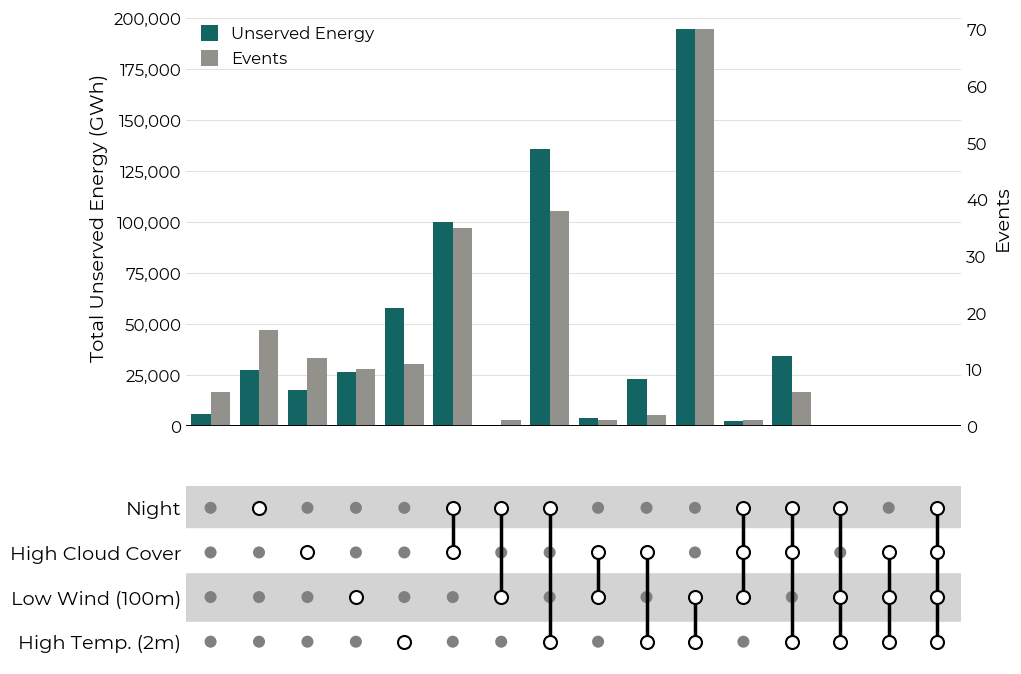

In [56]:
fig, _ax = plt.subplot_mosaic([['A'], ['B']], 
                               figsize = (10, 8.5), sharex=True,
                               gridspec_kw = {'wspace': 0.,
                                              'height_ratios': [0.7, 0.3]})

_plot_all_sets_USE_and_events(_ax['A'], df_upset_agg_)

_plot_upset_matrix(_ax['B'], combinations_, labels_)

# plt.savefig(path_to_images + '/upset_allsets.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

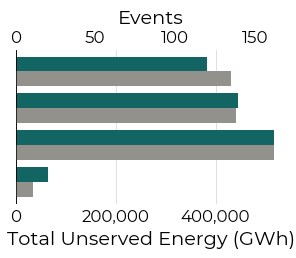

In [59]:
def _plot_main_sets_and_events(ax1, df_, labels_):

    pivot_ = pd.pivot_table(df_,
                            index= labels_,
                            values=["unserved_energy", "event"],
                            aggfunc="sum").reset_index()
    
    df_totals_ = pivot_.melt(id_vars=["event", "unserved_energy"],
                             value_vars=labels_,
                             var_name="condition",
                             value_name="flag")
    
    df_totals_ = df_totals_[df_totals_["flag"] == 1].groupby("condition").agg({"event": "sum",
                                                                               "unserved_energy": "sum"}).reset_index(drop = False)

    df = df_totals_.set_index("condition").loc[labels_].reset_index()

    x = np.arange(len(df))          # one position per "set"
    height = 0.4                    # bar width

    # --- Right y-axis: event number ---
    ax2 = ax1.twiny()

    # --- Left y-axis: unserved_energy ---
    bars1 = ax1.barh(x + height/2, df["unserved_energy"][::-1], height,
                     label="Unserved Energy",
                     color = '#136564', 
                     zorder = 4)

    ax1.set_xlabel("Total Unserved Energy (GWh)", fontsize = 14)
    ax1.tick_params(axis="x")

    bars2 = ax2.barh(x - height/2,
                     df["event"][::-1],
                     height,
                     label="Events",
                     color="#92918b", 
                     zorder = 4)

    ax2.set_xlabel("Events", fontsize = 14)
    ax2.tick_params(axis="x")

    ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax1.tick_params(axis="both", which="both", length=0)
    ax2.tick_params(axis="both", which="both", length=0)

    for spine in ["top", "left", "right", "bottom"]:
        ax1.spines[spine].set_visible(False)

    for spine in ["top", "left", "right", "bottom"]:
        ax2.spines[spine].set_visible(False)

    # Primary grid (unserved energy) – solid
    ax1.grid(axis="x", 
             linestyle="-", 
             linewidth=0.5,
             color="lightgray", 
             zorder=0)
    
    ax1.tick_params(axis="x", labelsize=12)
    ax2.tick_params(axis="x", labelsize=12)

    ax1.set_yticks([]) 
    ax1.set_yticklabels("")  # or "" to hide

    ax1.axvline(x=0, color = 'k', linestyle="-", linewidth=.5, zorder = 10)
    ax2.axvline(x=0, color = 'k', linestyle="-", linewidth=.5, zorder = 10)

fig, _ax = plt.subplots(figsize = (3.5, 2))

_plot_main_sets_and_events(_ax, df_upset_, labels_)

plt.savefig(path_to_images + '/upset_mainsets.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [14]:
df_2_ = t2m_.merge(ghi_, 
                   on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                   how = "inner")

df_2_ = tcc_.merge(df_2_, 
                   on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                   how = "inner")

df_2_ = tp_.merge(df_2_, 
                  on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                  how = "inner")

df_2_ = cs_.merge(df_2_, 
                  on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                  how = "inner")

df_2_ = wnd10m_.merge(df_2_, 
                      on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                      how = "inner")

df_2_ = wnd100m_.merge(df_2_, 
                       on = ['iteration', 'month', 'day', 'hour', 'load_zone'], 
                       how = "inner")
print(df_2_.shape)

(5518800, 33)


In [15]:
# 1) Keys for the dates + zones you care about (from A)
df_dates_ = df_1_[["month", 
                   "day", 
                   "hour", 
                   "load_zone"]].drop_duplicates()

# 2) Subset B to those dates + zones (keep all iterations there)
df_2_sub_ = df_2_.merge(df_dates_,
                        on=["month", "day", "hour", "load_zone"],
                        how="inner")

# 3) Take only needed columns from A (no 'set', no 'static_load')
df_1_sub_ = df_1_[["iteration", 
                   "month", 
                   "day", 
                   "hour", 
                   "load_zone", 
                   "unserved_energy"]].copy()

# 4) Merge A’s extra info onto B_sub (left join on full key)
df_events_ = df_2_sub_.merge(df_1_sub_,
                             on=["iteration", "month", "day", "hour", "load_zone"],
                             how="left")

# 5) New samples (from B only) get unserved_energy = 0 instead of NaN
df_events_["unserved_energy"] = df_events_["unserved_energy"].fillna(0)

df_events_ = df_events_[["iteration", 
                         "month", 
                         "day", 
                         "hour", 
                         "load_zone", 
                         "unserved_energy",
                         'wnd10m_pow', 
                         'wnd100m_wind', 
                         't2m_pow', 
                         'ghi_solar', 
                         'tcc_solar', 
                         'tp_pow', 
                         'cs_solar']].copy()

print(df_events_.shape)
print(df_events_["load_zone"].unique().shape)
# path_to_csvs = '/home/gterren/india_power/gridpath_india_viz/data/'
# df_events_.to_csv(path_to_csvs + 'LOLH_and_baseline_weather_data.csv', index = False)

(3708, 13)
(17,)


In [16]:
# 1) Keys for the dates you care about (from A)  <-- no load_zone
df_dates_ = df_1_[["month", "day", "hour"]].drop_duplicates()

# 2) Subset B to those dates (keep all iterations + all load_zones there)
df_2_sub_ = df_2_.merge(df_dates_, on=["month", "day", "hour"], how="inner")

# 3) Needed columns from A (keep zone + iteration so we can map UE correctly)
df_1_sub_ = df_1_[["iteration", 
                   "month", 
                   "day", 
                   "hour", 
                   "load_zone", 
                   "unserved_energy"]].copy()

# 4) Merge A’s UE onto B_sub (left join so "new" samples in B get NaN -> 0)
df_all_events_ = df_2_sub_.merge(df_1_sub_, on=["iteration", "month", "day", "hour", "load_zone"], how="left")

# 5) New samples (from B only) get unserved_energy = 0
df_all_events_["unserved_energy"] = df_all_events_["unserved_energy"].fillna(0)

df_all_events_ = df_all_events_[["iteration", 
                                 "month", 
                                 "day", 
                                 "hour", 
                                 "load_zone", 
                                 "unserved_energy",
                                 "wnd10m_pow", 
                                 "wnd100m_wind", 
                                 "t2m_pow", 
                                 "ghi_solar", 
                                 "tcc_solar",
                                 "tp_pow", 
                                 "cs_solar"]].copy()

print(df_all_events_)
print(df_all_events_["load_zone"].unique().shape)

       iteration  month  day  hour      load_zone  unserved_energy  \
0              1      2    7     7          India              0.0   
1              1      2    7    17          India              0.0   
2              1      2    9     7          India              0.0   
3              1      2    9     9          India              0.0   
4              1      2   10     7          India              0.0   
...          ...    ...  ...   ...            ...              ...   
54805          1     12    2    18  Jammu_Kashmir              0.0   
54806          1     12   13     7  Jammu_Kashmir              0.0   
54807          1     12   13    17  Jammu_Kashmir              0.0   
54808          1     12   29     9  Jammu_Kashmir              0.0   
54809          1     12   29    15  Jammu_Kashmir              0.0   

       wnd10m_pow  wnd100m_wind    t2m_pow   ghi_solar  tcc_solar    tp_pow  \
0        6.597189     17.153063  15.039952   10.305360  33.777014  0.063494   
1

In [ ]:
data_ = [
    # wnd100m
    ("Andhra_Pradesh", "wnd100m_wind"),
    #("Dadra_Nagar_Haveli", "wnd100m"),
    #("Goa", "wnd100m"),
    ("Gujarat", "wnd100m_wind"),
    ("Kerala", "wnd100m_wind"),
    ("Maharashtra", "wnd100m_wind"),
    ("Tamil_Nadu", "wnd100m_wind"),
    ("Telangana", "wnd100m_wind"),

    # t2m
    ("Delhi", "t2m_pow"),
    #("Chandigarh", "t2m_pow"),
    ("Uttar_Pradesh", "t2m_pow"),
    ("Uttarakhand", "t2m_pow"),

    # tcc
    ("Andhra_Pradesh", "tcc_solar"),
    #("Chandigarh", "tcc"),
    #("Delhi", "tcc"),
    ("Gujarat", "tcc_solar"),
    ("Karnataka", "tcc_solar"),
    ("Kerala", "tcc_solar"),
    ("Maharashtra", "tcc_solar"),
    ("Puducherry", "tcc_solar"),
    ("Tamil_Nadu", "tcc_solar"),

    # tp
    #("Puducherry", "tp_pow"),
    #("Kerala", "tp_pow"),
    ("Tamil_Nadu", "tp_pow"),
    ("Karnataka", "tp_pow"),
    ("Telangana", "tp_pow"),
    #("Uttar_Pradesh", "tp_pow"),
    #("Uttarakhand", "tp_pow"),
]

df_lz_use_    = pd.DataFrame(data_, columns=["load_zone", "feature"])
#df_lz_exports_ = ['India', 'Rajasthan', "Gujarat", 'Tamil_Nadu', 'Karnataka', 'Andhra_Pradesh']
df_lz_exports_ = ['India', 'Rajasthan', "Gujarat"]
print(df_lz_use_)

         load_zone       feature
0   Andhra_Pradesh  wnd100m_wind
1          Gujarat  wnd100m_wind
2           Kerala  wnd100m_wind
3      Maharashtra  wnd100m_wind
4       Tamil_Nadu  wnd100m_wind
5        Telangana  wnd100m_wind
6            Delhi       t2m_pow
7       Chandigarh       t2m_pow
8    Uttar_Pradesh       t2m_pow
9      Uttarakhand       t2m_pow
10  Andhra_Pradesh     tcc_solar
11         Gujarat     tcc_solar
12       Karnataka     tcc_solar
13          Kerala     tcc_solar
14     Maharashtra     tcc_solar
15      Puducherry     tcc_solar
16      Tamil_Nadu     tcc_solar
17      Tamil_Nadu        tp_pow
18       Karnataka        tp_pow
19       Telangana        tp_pow


Delhi
$\delta=-0.43^{}$
Chandigarh
$\delta=-0.32^{}$
Uttar_Pradesh
$\delta=-0.52^{(†)}$
Uttarakhand
$\delta=-0.41^{(†)}$


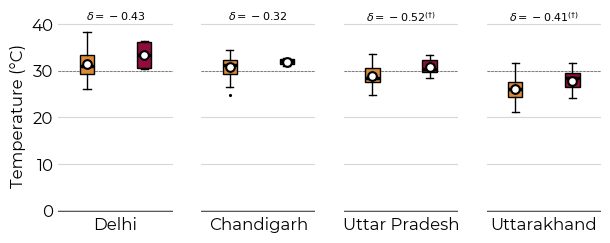

In [23]:
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

def _cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (nx * ny)

def _pvalues(p, symbol = "†"):
    if p < 0.001:
        return f"({symbol}{symbol}{symbol})"
    elif p < 0.01:
        return f"({symbol}{symbol})"
    elif p < 0.05:
        return f"({symbol})"
    else:
        return ""

def _plot_boxplots(ax, control_, treatment_, ylabel, color, ymin = 0, ymax = None, axhl = 0):

    labels_ = ['REF', 'USE']

    box = ax.boxplot([control_, treatment_],
                     zorder = 2,
                     widths=0.25,
                     patch_artist=True,
                     capprops=dict(linewidth=1),
                     medianprops=dict(linewidth=2.5, color="k"),
                     showfliers=True,
                     showmeans=True,
                     meanprops=dict(marker="o",
                                    markerfacecolor="white",   # fill color
                                    markeredgecolor="black",   # edge color
                                    markersize=6.25,
                                    markeredgewidth=1.5),
                     flierprops=dict(marker="o",           # circular
                                     markersize=1.25,         # small dots
                                     markerfacecolor="black",
                                     markeredgecolor="black",
                                     linestyle="none"))

    ax.axhline(y=axhl, linestyle="--", linewidth=.5, color = 'k', zorder = 1)
    ax.axhline(y=0, linestyle="-", linewidth=1, color = 'k', zorder = 1)

    # Your custom colors (one per box)
    colors_ = ["#d98b3a", color]  # extend if more boxes
    alpha_ = [1., 1.]  # extend if more boxes

    for patch, color, alpha in zip(box["boxes"], colors_, alpha_):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_alpha(alpha)      # optional

    #ax.set_xticks(range(1, len(labels_) + 1))
    #ax.set_xticklabels(labels_, rotation = 90)
    ax.set_xticklabels([])

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="y", linestyle="-", alpha=0.5, zorder = 0)
    ax.set_ylabel(ylabel, fontsize = 12)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

features_ = ['wnd100m_wind', 't2m_pow', 'tcc_solar', 'tp_pow', 'ghi_solar',  "wnd10m_pow"]
colors_   = [ '#2cb7b5', '#900C3F', '#92918b', '#136564', '#136564', '#136564' ]
ymax_     = [50, 41, 101, 1.5, None, None]
ymin_     = [-.25, -.25, -1, -.025, -.25, -0.25]
highs_    = [12, 30, 40, .1, 0, 0]
ylabels_  = ['Wind Speed at 100m (km/h)', 
             'Temperature (°C)', 
             'Cloud Cover (%)',
             'Precipitation (mm/h)',
             'GHI (W/m²)',
             'Wind Speed at 10m (km/h)']

i_feature   = 1
ylabel      = ylabels_[i_feature]
load_zones_ = df_lz_use_.loc[df_lz_use_['feature'] == features_[i_feature], 'load_zone'].tolist()

fig, _ax = plt.subplot_mosaic([load_zones_], 
                               figsize = (len(load_zones_)*1.75, 2.5), sharey=True,
                               gridspec_kw = {'wspace': 0.25,
                                              'width_ratios': [1] * len(load_zones_)})

for load_zone, ax in _ax.items():
    print(load_zone)

    df_lz_events_ = df_events_[df_events_['load_zone'] == load_zone].reset_index(drop = True).copy()

    idx_use_  = df_lz_events_['unserved_energy'] > 0.
    control   = df_lz_events_.loc[~idx_use_,features_[i_feature]].to_numpy()
    treatment = df_lz_events_.loc[idx_use_,features_[i_feature]].to_numpy()

    _plot_boxplots(ax, control, treatment, 
                   ylabel = ylabel, 
                   color  = colors_[i_feature], 
                   ymax   = ymax_[i_feature], 
                   ymin   = ymin_[i_feature],
                   axhl   = highs_[i_feature])
    
    stat, mannwhitney = mannwhitneyu(control, treatment, alternative = "two-sided")
    stat, ttest       = ttest_ind(control, treatment, equal_var = False)
    ttest             = _pvalues(ttest, symbol = "*")
    mannwhitney       = _pvalues(mannwhitney, symbol = "†")
    cliffs_delta      = _cliffs_delta(control, treatment)
    text              = f'$\delta={cliffs_delta:.2f}^{{{mannwhitney}{ttest}}}$'
    print(text)
    ax.text(0.5, 1.05, text,
            transform=ax.transAxes,
            ha="center", 
            va="top",
            fontsize=8)

    load_zone = load_zone.replace('Daman_Diu', 'Demand & Diu')
    load_zone = load_zone.replace('Dadra_Nagar_Haveli', ' Dadra Nagar & Haveli')
    load_zone = load_zone.replace('Jammu_Kashmir', 'Jammu & Kashmir')
    load_zone = load_zone.replace('_', ' ')

    ax.set_title(f'{load_zone}', 
                 loc      = 'center', 
                 y        = -0.1375, 
                 fontsize = 12)

    ylabel = ''

plt.savefig(path_to_images + f'/state-level_boxplot_{features_[i_feature]}.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

India
(1566,) (77,)
$\delta=-0.00^{}$
Rajasthan
(1566,) (77,)
$\delta=-0.00^{}$
Gujarat
(1566,) (77,)
$\delta=-0.04^{}$


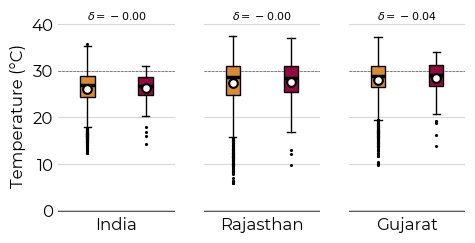

In [22]:
features_ = ['wnd100m_wind', 't2m_pow', 'tcc_solar', 'tp_pow', 'ghi_solar',  "wnd10m_pow"]
colors_   = [ '#2cb7b5', '#900C3F', '#92918b', '#136564', '#136564', '#136564' ]
daytimes_ = [False, False, True, False, True, True]
ymax_     = [50, 41, 101, 1.5, None, None]
ymin_     = [-.25, -.25, -1, -.025, -.25, -0.25]
highs_    = [12, 30, 40, .1, 0, 0]
ylabels_  = ['Wind Speed at 100m (km/h)', 
             'Temperature (°C)', 
             'Cloud Cover (%)',
             'Precipitation (mm/h)',
             'GHI (W/m²)',
             'Wind Speed at 10m (km/h)']

i_feature   = 1
ylabel      = ylabels_[i_feature]
load_zones_ = df_lz_exports_

fig, _ax = plt.subplot_mosaic([load_zones_], 
                               figsize = (len(load_zones_)*1.75, 2.5), sharey=True,
                               gridspec_kw = {'wspace': 0.25,
                                              'width_ratios': [1] * len(load_zones_)})

for load_zone, ax in _ax.items():
    print(load_zone)

    df_lz_events_ = df_all_events_[df_all_events_['load_zone'] == load_zone].reset_index(drop = True).copy()
    
    idx_use_     = df_all_events_['unserved_energy'] > 0.
    idx_daytime_ = (df_all_events_['hour'] > 7) & (df_all_events_['hour'] < 17)

    if daytimes_[i_feature]:
        idx_ = idx_use_ & idx_daytime_
    else:
        idx_daytime_ = ~idx_daytime_
        idx_         = idx_use_ & idx_daytime_

    df_events_treatment_ = df_all_events_.loc[idx_, ["iteration", "month", "day", "hour"]].drop_duplicates()
    df_events_control_   = df_all_events_.loc[~idx_, ["iteration", "month", "day", "hour"]].drop_duplicates()

    treatment = df_lz_events_.merge(df_events_treatment_, on=["iteration", "month", "day", "hour"], how="inner")[features_[i_feature]].to_numpy()
    control   = df_lz_events_.merge(df_events_control_, on=["iteration", "month", "day", "hour"], how="inner")[features_[i_feature]].to_numpy()
    print(control.shape, treatment.shape)

    _plot_boxplots(ax, control, treatment, 
                   ylabel = ylabel, 
                   color  = colors_[i_feature], 
                   ymax   = ymax_[i_feature], 
                   ymin   = ymin_[i_feature],
                   axhl   = highs_[i_feature])
    
    stat, mannwhitney = mannwhitneyu(control, treatment, alternative = "two-sided")
    stat, ttest       = ttest_ind(control, treatment, equal_var = False)
    ttest             = _pvalues(ttest, symbol = "*")
    mannwhitney       = _pvalues(mannwhitney, symbol = "†")
    cliffs_delta      = _cliffs_delta(control, treatment)
    text              = f'$\delta={cliffs_delta:.2f}^{{{mannwhitney}{ttest}}}$'
    print(text)
    ax.text(0.5, 1.05, text,
            transform=ax.transAxes,
            ha="center", 
            va="top",
            fontsize=8)

    load_zone = load_zone.replace('Daman_Diu', 'Demand & Diu')
    load_zone = load_zone.replace('Dadra_Nagar_Haveli', ' Dadra Nagar & Haveli')
    load_zone = load_zone.replace('Jammu_Kashmir', 'Jammu & Kashmir')
    load_zone = load_zone.replace('_', ' ')

    ax.set_title(f'{load_zone}', 
                 loc      = 'center', 
                 y        = -0.1375, 
                 fontsize = 12)

    ylabel = ''

plt.savefig(path_to_images + f'/export_boxplot_{features_[i_feature]}.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [22]:
# def _plot_boxplots(ax, df_events_, feature, ylabel, color):

#     idx_ = df_events_['unserved_energy'] > 0

#     labels_ = ['USE', 'REF']
#     box = ax.boxplot([df_events_.loc[idx_, feature], df_events_.loc[~idx_, feature]],
#                 widths=0.35,
#                 patch_artist=True,
#                 capprops=dict(linewidth=1),
#                 medianprops=dict(linewidth=2.5, color="k"),
#                 #howfliers=False,
#                 showmeans=True,
#                 meanprops=dict(marker="o",
#                                markerfacecolor="white",   # fill color
#                                markeredgecolor="black",   # edge color
#                                markersize=8,
#                                markeredgewidth=1.5),
#                 flierprops=dict(marker="o",           # circular
#                                 markersize=1.25,         # small dots
#                                 markerfacecolor="black",
#                                 markeredgecolor="black",
#                                 linestyle="none"))

#     # Your custom colors (one per box)
#     colors_ = [color, "#d98b3a"]  # extend if more boxes
#     alpha_ = [1., 1.]  # extend if more boxes

#     for patch, color, alpha in zip(box["boxes"], colors_, alpha_):
#         patch.set_facecolor(color)
#         patch.set_edgecolor("black")
#         patch.set_alpha(alpha)      # optional

#     ax.set_xticks(range(1, len(labels_) + 1))
#     ax.set_xticklabels(labels_)

#     for spine in ["top",  "right", ]:
#         ax.spines[spine].set_visible(False)

#     ax.set_ylabel(ylabel, fontsize = 14)
#     #ax.set_ylim(0,)

#     ax.tick_params(axis="x", labelsize=12)
#     ax.tick_params(axis="y", labelsize=12)


# features_ = ['wnd10m_pow', 
#              'wnd100m_wind', 
#              't2m_pow', 
#              'ghi_solar', 
#              'tcc_solar', 
#              'tp_pow', 
#              'cs_solar']

# ylabels_ = ['Wind Speed at 10m (km/h)', 
#             'Wind Speed at 100m (km/h)', 
#             'Temperature at 2m (°C)', 
#             'Solar Radiation (W/m²)', 
#             'Cloud Cover (%)', 
#             'Precipitation (m/s)', 
#             'Clear-Sky Radiation (W/m²)']

# fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E']], 
#                                figsize = (15, 4), 
#                                gridspec_kw = {'wspace': .5,
#                                               'width_ratios': [1, 1, 1, 1, 1]})

# for label, ax in _ax.items():
#     ax.text(0.0, 1.0, label, 
#             transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
#             fontsize  = 18, 
#             weight    = "bold",
#             va        = 'bottom',
#             family    = 'Arial')

# i = 1
# _plot_boxplots(_ax['A'], df_events_, features_[i], ylabels_[i], color = '#92918b')

# i = 2
# _plot_boxplots(_ax['B'], df_events_, features_[i], ylabels_[i], color = '#136564')

# i = 3
# _plot_boxplots(_ax['C'], df_events_, features_[i], ylabels_[i], color = '#2cb7b5')

# i = 6
# _plot_boxplots(_ax['D'], df_events_, features_[i], ylabels_[i], color = '#756a01')

# i = 4
# _plot_boxplots(_ax['E'], df_events_, features_[i], ylabels_[i], color = '#900C3F')

# plt.savefig(path_to_images + '/boxplot_mainsets.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

# plt.tight_layout()
# plt.show()

In [72]:
# import seaborn as sns
# # --- feature & label selection ---
# feature = ['wnd10m_pow', 
#            'wnd100m_wind', 
#            't2m_pow', 
#            'ghi_solar', 
#            'tcc_solar', 
#            'tp_pow', 
#            'cs_solar'][2]

# ylabel = ['Wind Speed at 10m (km/h)', 
#           'Wind Speed at 100m (km/h)', 
#           'Temperature at 2m (°C)', 
#           'Solar Radiation (W/m²)', 
#           'Cloud Cover (%)', 
#           'Precipitation (m/s)', 
#           'Solar Radiation (W/m²)'][2]

# # --- define USE vs REF ---
# idx_ = df_events_['unserved_energy'] > 0
# labels_ = ['USE', 'REF']
# colors_ = ["#136564", "#d98b3a"]

# # Create a long-form DataFrame for seaborn
# df_plot = df_events_.copy()
# df_plot["group"] = np.where(idx_, "USE", "REF")

# # --- plot ---
# fig, ax = plt.subplots(figsize=(2.5, 4))

# sns.violinplot(
#     data=df_plot,
#     x="group",
#     y=feature,
#     order=labels_,
#     palette=colors_,
#     cut=0,           # don't extend beyond data range
#     inner=None,      # no internal box/points; we'll control markers ourselves
#     linewidth=1,
#     ax=ax,
# )


# # Optional: add mean markers like before
# means = df_plot.groupby("group")[feature].mean()
# for i, g in enumerate(labels_):
#     ax.scatter(
#         i, means[g],
#         s=50,
#         facecolor="black",
#         edgecolor="black",
#         marker = '^',
#         zorder=5,
#     )

# # Optional: add mean markers like before
# median = df_plot.groupby("group")[feature].median()
# for i, g in enumerate(labels_):
#     ax.scatter(
#         i, median[g],
#         s=50,
#         facecolor="white",
#         edgecolor="white",
#         zorder=5,
#     )

# # Styling (similar to your boxplot)
# ax.set_xlabel("")
# ax.set_ylabel(ylabel, fontsize=14)
# ax.set_xticks(range(len(labels_)))
# ax.set_xticklabels(labels_)

# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)

# ax.tick_params(axis="x", labelsize=12)
# ax.tick_params(axis="y", labelsize=12)

# plt.tight_layout()
# plt.show()


In [70]:
# df_med_events_ = df_events_.groupby(['load_zone']).agg({'wnd10m_pow': 'median',
#                                                         'wnd100m_wind': 'median',
#                                                         't2m_pow': 'median',
#                                                         'ghi_solar': 'median',
#                                                         'tcc_solar': 'median',
#                                                         'tp_pow': 'median',
#                                                         'cs_solar': 'median'}).reset_index(drop = False)

# print(df_med_events_.shape)

# df_max_events_ = df_events_.groupby(['load_zone']).agg({'wnd10m_pow': 'max',
#                                                         'wnd100m_wind': 'max',
#                                                         't2m_pow': 'max',
#                                                         'ghi_solar': 'max',
#                                                         'tcc_solar': 'max',
#                                                         'tp_pow': 'max',
#                                                         'cs_solar': 'max'}).reset_index(drop = False)

# df_stats_events_ = df_med_events_.merge(df_events_, 
#                                         on = ['load_zone'], 
#                                         how = "left", 
#                                         suffixes=("_med", "")).reset_index(drop = True)

# df_stats_events_ = df_max_events_.merge(df_stats_events_, 
#                                         on = ['load_zone'], 
#                                         how = "left", 
#                                         suffixes=("_max", "")).reset_index(drop = True)

# print(df_stats_events_.columns)

# #df_stats_events_['wnd10m_metric']  = 100.*(df_stats_events_['wnd10m_pow'] - df_stats_events_['wnd10m_pow_med'])/(df_stats_events_['wnd10m_pow_max'] - df_stats_events_['wnd10m_pow_med'])
# df_stats_events_['t2m_metric']     = 100.*(df_stats_events_['t2m_pow'] - df_stats_events_['t2m_pow_med'])/(df_stats_events_['t2m_pow_max'] - df_stats_events_['t2m_pow_med'])
# df_stats_events_['tcc_metric']     = 100.*(df_stats_events_['tcc_solar'] - df_stats_events_['tcc_solar_med'])/(df_stats_events_['tcc_solar_max'] - df_stats_events_['tcc_solar_med'])
# df_stats_events_['tp_metric']      = 100.*(df_stats_events_['tp_pow'] - df_stats_events_['tp_pow_med'])/(df_stats_events_['tp_pow_max'] - df_stats_events_['tp_pow_med'])

# df_stats_events_['wnd10m_metric']  = -100.*(df_stats_events_['wnd10m_pow'] - df_stats_events_['wnd10m_pow'])/df_stats_events_['wnd10m_pow']
# df_stats_events_['wnd100m_metric'] = -100.*(df_stats_events_['wnd100m_wind'] - df_stats_events_['wnd100m_wind_med'])/df_stats_events_['wnd100m_wind_med']
# df_stats_events_['ghi_metric']     = -100.*(df_stats_events_['ghi_solar'] - df_stats_events_['ghi_solar_med'])/df_stats_events_['ghi_solar_med']
# df_stats_events_['cs_metric']      = -100.*(df_stats_events_['cs_solar'] - df_stats_events_['cs_solar_med'])/df_stats_events_['cs_solar_med']

# df_metrics_ = df_stats_events_[['iteration', 
#                                 'month', 
#                                 'day', 
#                                 'hour', 
#                                 'load_zone',
#                                 'unserved_energy',
#                                 'wnd10m_metric',
#                                 'wnd100m_metric',
#                                 't2m_metric',
#                                 'ghi_metric', 
#                                 'tcc_metric', 
#                                 'tp_metric', 
#                                 'cs_metric']].copy()

# df_metrics_.loc[df_metrics_['wnd10m_metric'] < 0, 'wnd10m_metric']   = 0
# df_metrics_.loc[df_metrics_['wnd100m_metric'] < 0, 'wnd100m_metric'] = 0
# df_metrics_.loc[df_metrics_['t2m_metric'] < 0, 't2m_metric']         = 0
# df_metrics_.loc[df_metrics_['tcc_metric'] < 0, 'tcc_metric']         = 0
# df_metrics_.loc[df_metrics_['tp_metric'] < 0, 'tp_metric']           = 0

# df_metrics_['wnd100m_t2m_metric']     = df_metrics_['wnd100m_metric'] + df_metrics_['t2m_metric'] 
# df_metrics_['wnd100m_tcc_metric']     = df_metrics_['tcc_metric'] + df_metrics_['wnd100m_metric'] 
# df_metrics_['tcc_t2m_metric']         = df_metrics_['tcc_metric'] + df_metrics_['t2m_metric'] 
# df_metrics_['wnd100m_tcc_t2m_metric'] = df_metrics_['wnd100m_metric']  + df_metrics_['t2m_metric'] + df_metrics_['tcc_metric']
# print(df_metrics_.shape)
# print(df_metrics_.columns)

In [71]:
# from scipy.stats import wilcoxon
# from scipy.stats import mannwhitneyu
# from scipy.stats import ttest_ind

# def _cliffs_delta(x, y):
#     nx, ny = len(x), len(y)
#     return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (nx * ny)

# #score = 'tcc_metric'
# #score = 'wind100m_metric'
# #score = 'tp_metric'
# #score = 't2m_metric'

# df_lz_feature_ = []
# for load_zone in df_events_['load_zone'].unique():

#     # df_events_lz_ = df_events_.loc[df_events_['load_zone'] == load_zone].reset_index(drop = True)
#     df_events_lz_ = df_events_[df_events_["load_zone"] == load_zone].reset_index(drop = True)
#     idx_ = df_events_['unserved_energy'] > 0.

#     for feature in ['wnd100m_wind', 't2m_pow', 'tcc_solar', 'tp_pow', 'ghi_solar',  "wnd10m_pow"]:
#         #treatment = df_events_lz_.loc[idx_,feature ].to_numpy()
#         #control   = df_events_lz_.loc[~idx_, feature].to_numpy()

#         df_event_treatment_ = df_events_.loc[idx_, ["iteration", "month", "day", "hour"]].drop_duplicates()
#         df_event_control_   = df_events_.loc[~idx_, ["iteration", "month", "day", "hour"]].drop_duplicates()
        
#         treatment = df_events_lz_.merge(df_event_treatment_, on=["iteration", "month", "day", "hour"], how="inner")[feature].to_numpy()
#         control = df_events_lz_.merge(df_event_control_, on=["iteration", "month", "day", "hour"], how="inner")[feature].to_numpy()

#         #print(wilcoxon(control, treatment))
#         stat, pvalue_mannwhitney = mannwhitneyu(control, treatment, alternative = "two-sided")
#         stat, pvaluet_ttest      = ttest_ind(control, treatment, equal_var = False)
#         cliffs_delta             = _cliffs_delta(control, treatment)
#         #med_delta                = np.median(df_metrics_lz_.loc[idx_, score].to_numpy()) - np.median(df_metrics_lz_.loc[~idx_, score].to_numpy())
        
#         x_ = [load_zone, 
#               feature, 
#               pvalue_mannwhitney, 
#               pvaluet_ttest, 
#               cliffs_delta]
        
#         df_lz_feature_.append(x_)
        
# df_lz_feature_ = pd.DataFrame(df_lz_feature_, columns = ['load_zone', 
#                                                          'feature', 
#                                                          'pvalue_mannwhitney',
#                                                          'pvaluet_ttest', 
#                                                          'cliffs_delta'])
# print(df_lz_feature_.shape)